# ''' 
Heart Disease Prediction System: This system uses patient clinical data like age, BP, cholesterol, etc. Data is cleaned, missing values removed
, and scaling is applied so all features are in same range. Feature selection means selecting most important attributes (like cholesterol, BP) so
model becomes fast and accurate. Logistic Regression and KNN are trained to classify risk or no risk. Performance is checked using accuracy,
precision, recall, and F1-score.
'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\siddh\OneDrive\Desktop\PBL1\Heart_Disease_3000_Medical6.csv")
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,NaN,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,75.0,0.0,3.0,142.0,197.0,NaN,1.0,132.0,1.0,1.52,2.0,0.0,6.0,NaN
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,NaN,0.0,1.93,2.0,2.0,NaN,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,NaN,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      2853 non-null   float64
 1   Sex                      2778 non-null   float64
 2   Chest pain type          2798 non-null   float64
 3   BP                       2818 non-null   float64
 4   Cholesterol              2810 non-null   float64
 5   FBS over 120             2821 non-null   float64
 6   EKG results              2815 non-null   float64
 7   Max HR                   2815 non-null   float64
 8   Exercise angina          2815 non-null   float64
 9   ST depression            2819 non-null   float64
 10  Slope of ST              2811 non-null   float64
 11  Number of vessels fluro  2800 non-null   float64
 12  Thallium                 2793 non-null   float64
 13  Heart Disease            2609 non-null   float64
dtypes: float64(14)
memory usage: 328.3 

In [4]:
data.shape

(3000, 14)

In [5]:
data.size

42000

In [6]:
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,NaN,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0


In [7]:
data.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
2995,75.0,0.0,3.0,142.0,197.0,NaN,1.0,132.0,1.0,1.52,2.0,0.0,6.0,NaN
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,NaN,0.0,1.93,2.0,2.0,NaN,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,NaN,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0
2999,46.0,1.0,4.0,124.0,207.0,0.0,2.0,180.0,0.0,0.51,3.0,3.0,6.0,NaN


In [8]:
data.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,2853.000000,2778.000000,2798.000000,2818.000000,2810.000000,2821.000000,2815.000000,2815.000000,2815.000000,2819.000000,2811.000000,2800.000000,2793.000000,2609.000000
mean,55.823247,0.533248,2.605386,134.261922,227.724060,0.575179,1.072555,166.089469,0.542043,1.903977,2.029105,1.586845,5.527331,0.548046
std,16.431088,0.573665,1.293434,17.414092,42.271810,0.571383,0.941159,19.654265,0.572770,1.159939,0.953773,1.261596,1.941080,0.577781
min,30.000000,0.000000,1.000000,88.000000,95.000000,0.000000,0.000000,116.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,42.000000,0.000000,1.250000,122.000000,200.000000,0.000000,0.000000,152.000000,0.000000,1.020000,1.000000,1.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,134.000000,225.000000,1.000000,1.000000,165.000000,1.000000,1.810000,2.000000,2.000000,6.000000,1.000000
75%,68.000000,1.000000,4.000000,145.000000,252.000000,1.000000,2.000000,178.000000,1.000000,2.700000,3.000000,3.000000,7.000000,1.000000
max,111.978707,2.489381,7.031151,193.668288,371.643461,2.526346,4.287362,233.347601,2.497512,5.864030,5.280217,5.902788,12.166711,2.497512


In [9]:
data.isnull().sum()

Age                        147
Sex                        222
Chest pain type            202
BP                         182
Cholesterol                190
FBS over 120               179
EKG results                185
Max HR                     185
Exercise angina            185
ST depression              181
Slope of ST                189
Number of vessels fluro    200
Thallium                   207
Heart Disease              391
dtype: int64

In [10]:
# DATA CLEANING

In [11]:
data.dropna(how='all', inplace=True)
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,NaN,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0
5,50.0,0.0,1.0,130.0,218.0,0.0,2.0,174.0,0.0,1.46,2.0,2.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,75.0,0.0,3.0,142.0,197.0,NaN,1.0,132.0,1.0,1.52,2.0,0.0,6.0,NaN
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,NaN,0.0,1.93,2.0,2.0,NaN,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,NaN,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0


In [12]:
data.drop_duplicates(inplace=True)
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,NaN,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0
5,50.0,0.0,1.0,130.0,218.0,0.0,2.0,174.0,0.0,1.46,2.0,2.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,75.0,0.0,3.0,142.0,197.0,NaN,1.0,132.0,1.0,1.52,2.0,0.0,6.0,NaN
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,NaN,0.0,1.93,2.0,2.0,NaN,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,NaN,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0


In [13]:
data.isnull().sum()

Age                          0
Sex                         75
Chest pain type             55
BP                          35
Cholesterol                 43
FBS over 120                32
EKG results                 38
Max HR                      38
Exercise angina             38
ST depression               34
Slope of ST                 42
Number of vessels fluro     53
Thallium                    60
Heart Disease              244
dtype: int64

In [14]:
# Age (median)
data['Age'] = data['Age'].fillna(data['Age'].median())
# Sex (mode)
data['Sex'] = data['Sex'].fillna(data['Sex'].mode()[0])
# Chest pain type (mode)
data['Chest pain type'] = data['Chest pain type'].fillna(data['Chest pain type'].mode()[0])
# BP (median)
data['BP'] = data['BP'].fillna(data['BP'].median())
# Cholesterol (median)
data['Cholesterol'] = data['Cholesterol'].fillna(data['Cholesterol'].median())
# FBS (mode)
data['FBS over 120'] = data['FBS over 120'].fillna(data['FBS over 120'].mode()[0])
# EKG (mode)
data['EKG results'] = data['EKG results'].fillna(data['EKG results'].mode()[0])
# Max HR (mean)
data['Max HR'] = data['Max HR'].fillna(data['Max HR'].mean())
# Exercise angina (mode)
data['Exercise angina'] = data['Exercise angina'].fillna(data['Exercise angina'].mode()[0])
# ST depression (median)
data['ST depression'] = data['ST depression'].fillna(data['ST depression'].median())
# Slope (mode)
data['Slope of ST'] = data['Slope of ST'].fillna(data['Slope of ST'].mode()[0])
# Vessels (mode)
data['Number of vessels fluro'] = data['Number of vessels fluro'].fillna(data['Number of vessels fluro'].mode()[0])
# Thallium (mode)
data['Thallium'] = data['Thallium'].fillna(data['Thallium'].mode()[0])
# Target column (important)
data['Heart Disease'] = data['Heart Disease'].fillna(data['Heart Disease'].mode()[0])

In [15]:
data.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [16]:
# Removing Outliers

In [17]:
# Select numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
outlier_count = {}
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    outlier_count[col] = count

print("Outliers in each column:\n")
for k,v in outlier_count.items():
    print(f"{k}: {v}")

Outliers in each column:

Age: 2
Sex: 0
Chest pain type: 0
BP: 4
Cholesterol: 17
FBS over 120: 2
EKG results: 0
Max HR: 4
Exercise angina: 0
ST depression: 2
Slope of ST: 0
Number of vessels fluro: 2
Thallium: 0
Heart Disease: 0


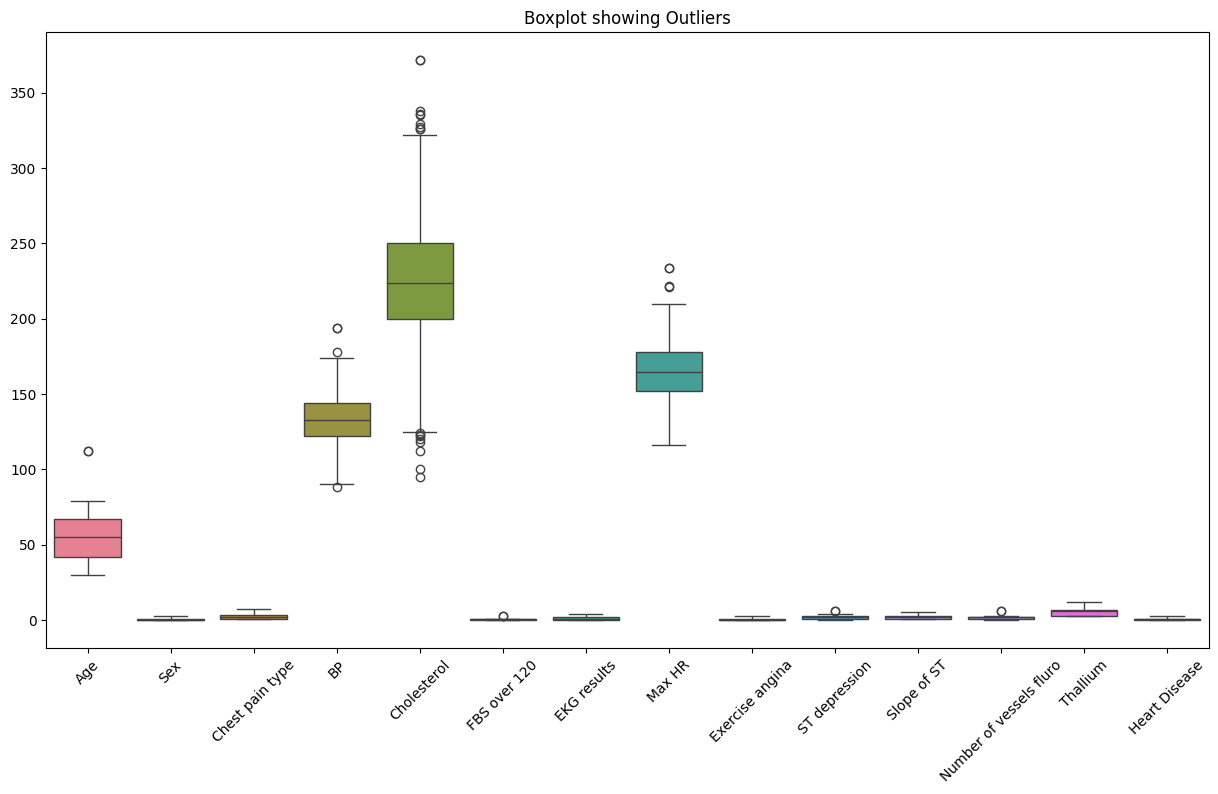

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.boxplot(data=data[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot showing Outliers")
plt.show()

In [19]:
# Inference : Detecting Outliers using boxplot

In [20]:
# Remove Outliers
data_clean = data.copy()

for col in numeric_cols:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_clean = data_clean[
        (data_clean[col] >= lower) & (data_clean[col] <= upper)
    ]

print("Shape before:", data.shape)
print("Shape after removing outliers:", data_clean.shape)

Shape before: (2795, 14)
Shape after removing outliers: (2775, 14)


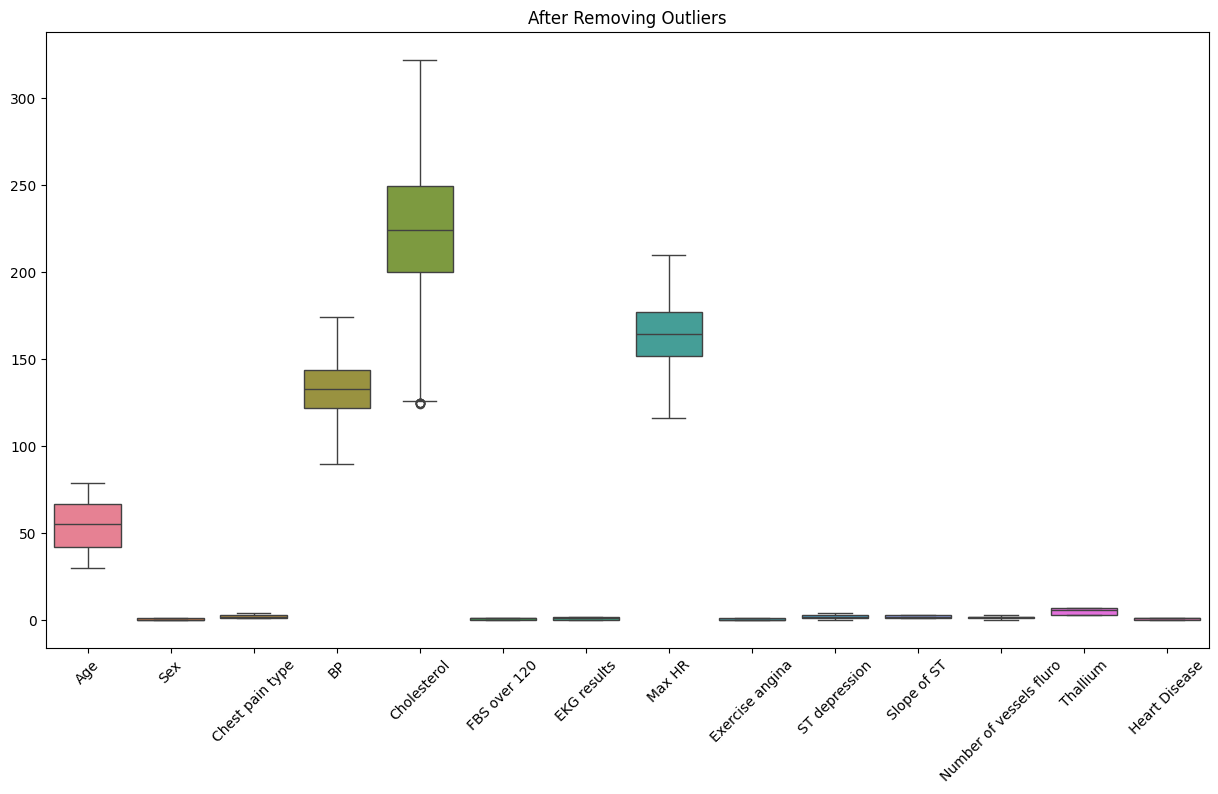

In [21]:
plt.figure(figsize=(15,8))
sns.boxplot(data=data_clean[numeric_cols])
plt.xticks(rotation=45)
plt.title("After Removing Outliers")
plt.show()

In [22]:
#Inference : data distribtuion shown after removing outliers

In [23]:
# plotting graphs 

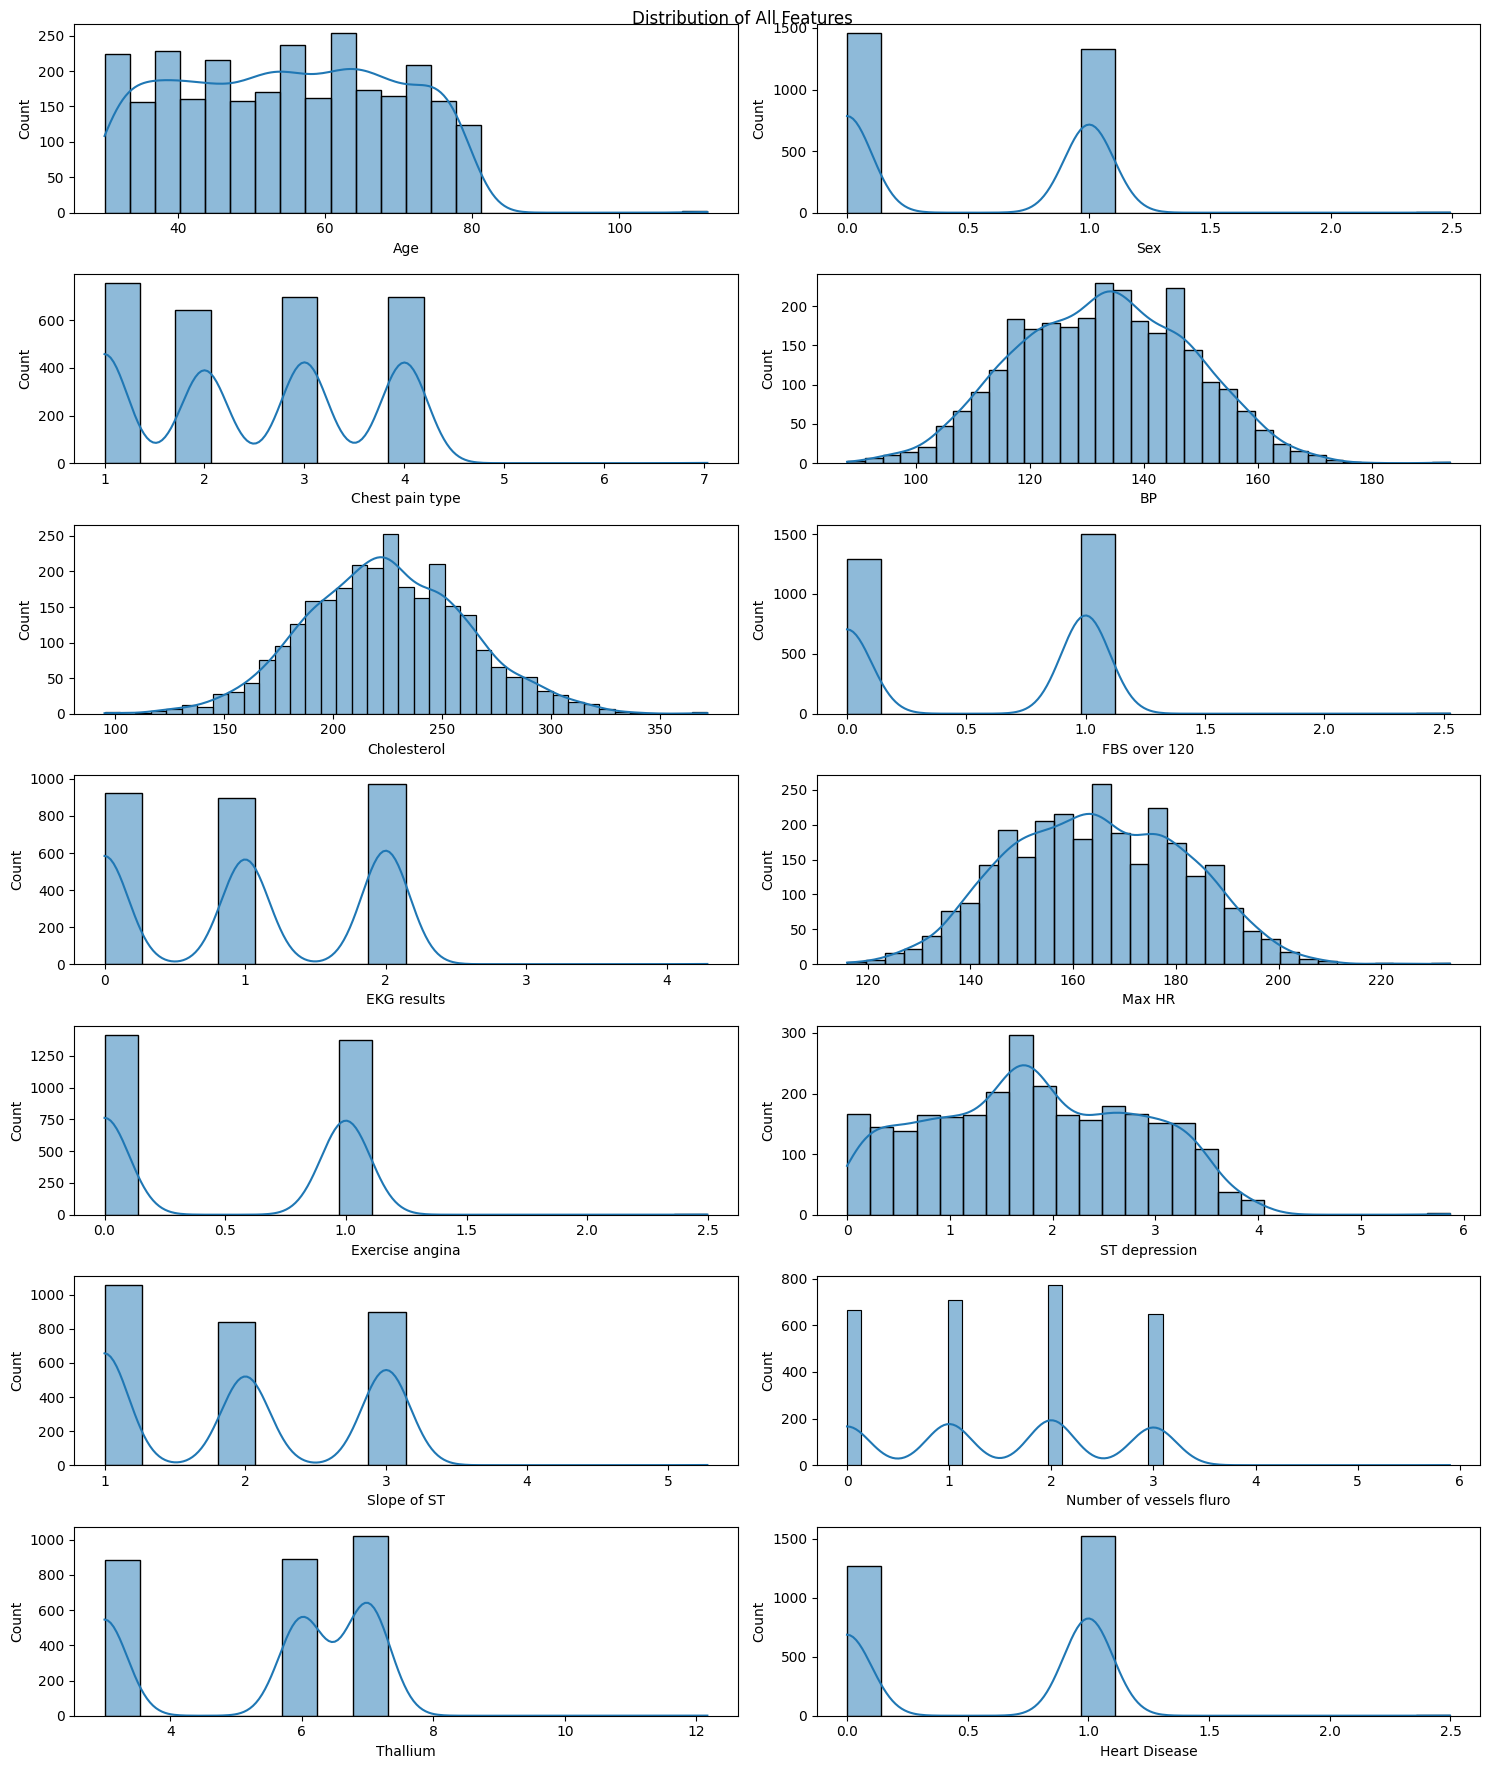

In [24]:
fig , axes = plt.subplots(7,2, figsize=(15,18))
axes= axes.flatten()
for i,col in enumerate(data.columns):
    sns.histplot(data[col] , kde=True , ax=axes[i])
    
plt.suptitle("Distribution of All Features ")
plt.tight_layout()
plt.show()

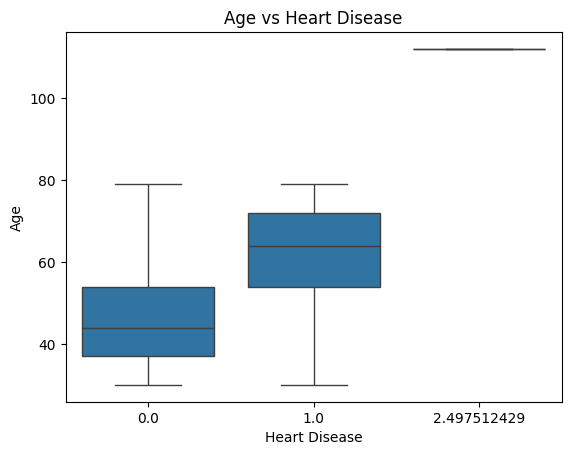

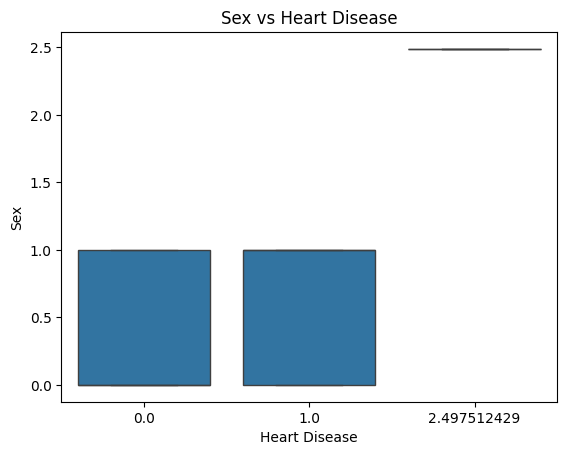

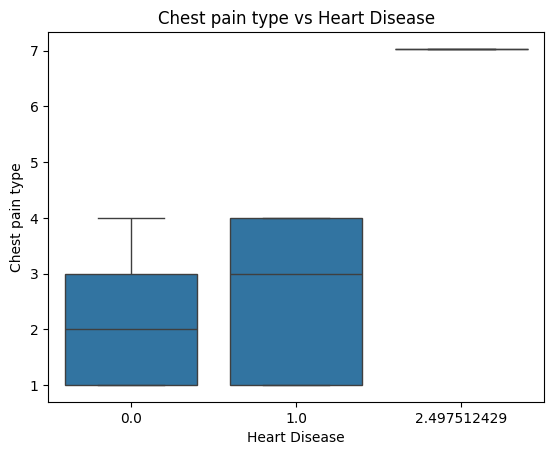

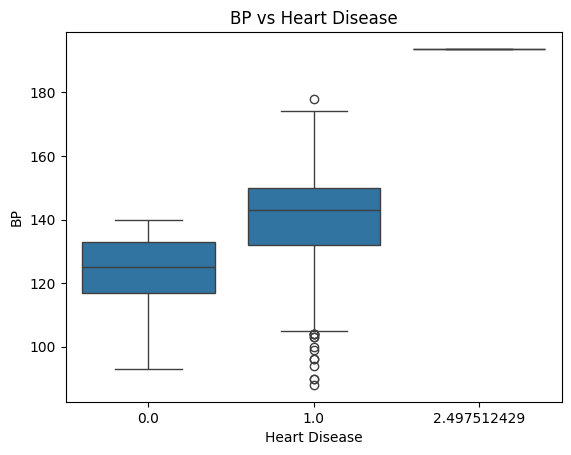

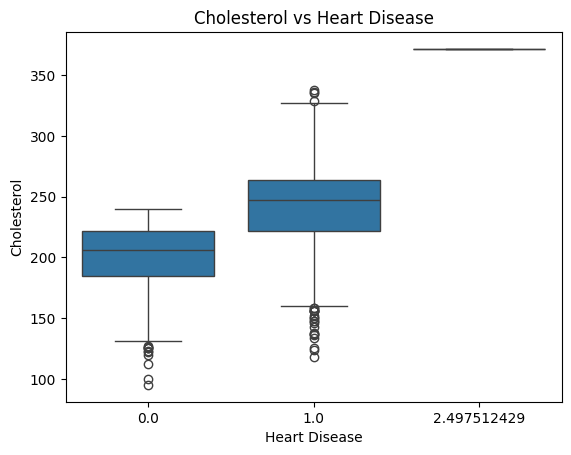

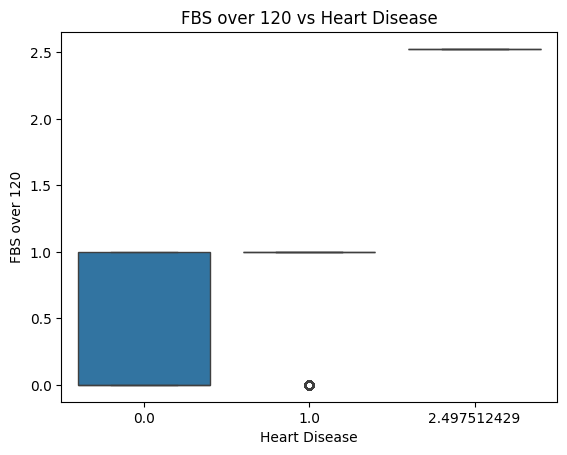

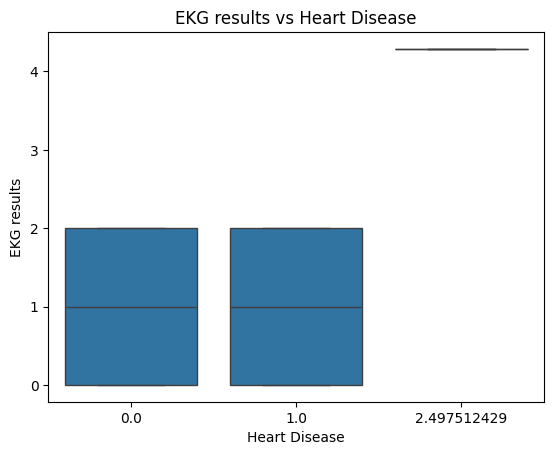

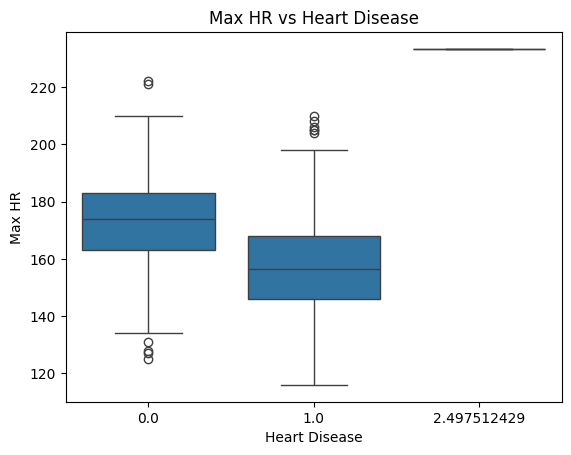

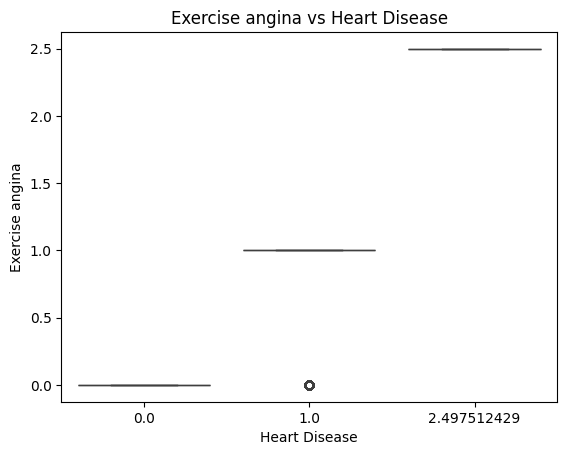

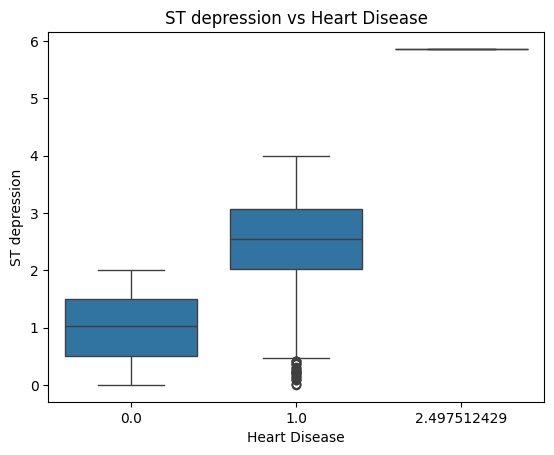

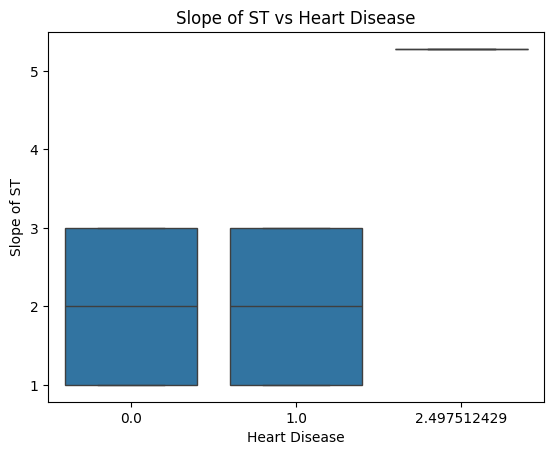

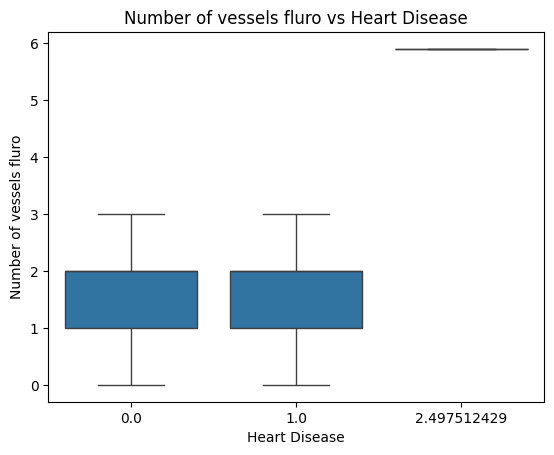

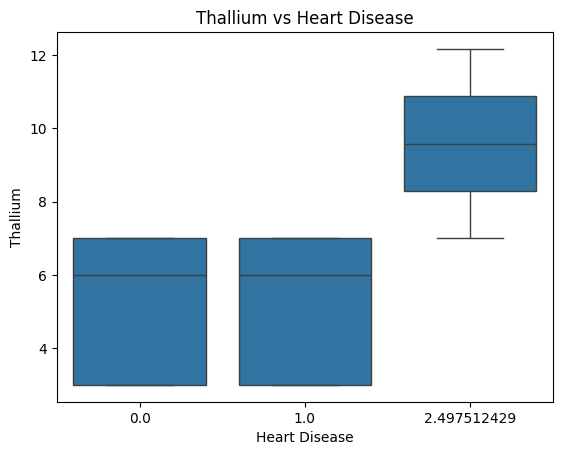

In [25]:
# Feature vs Target Graphs
target = 'Heart Disease'
for col in data.columns:
    if col != target:
        plt.figure()
        sns.boxplot(x=data[target], y=data[col])
        plt.title(f"{col} vs Heart Disease")
        plt.show()

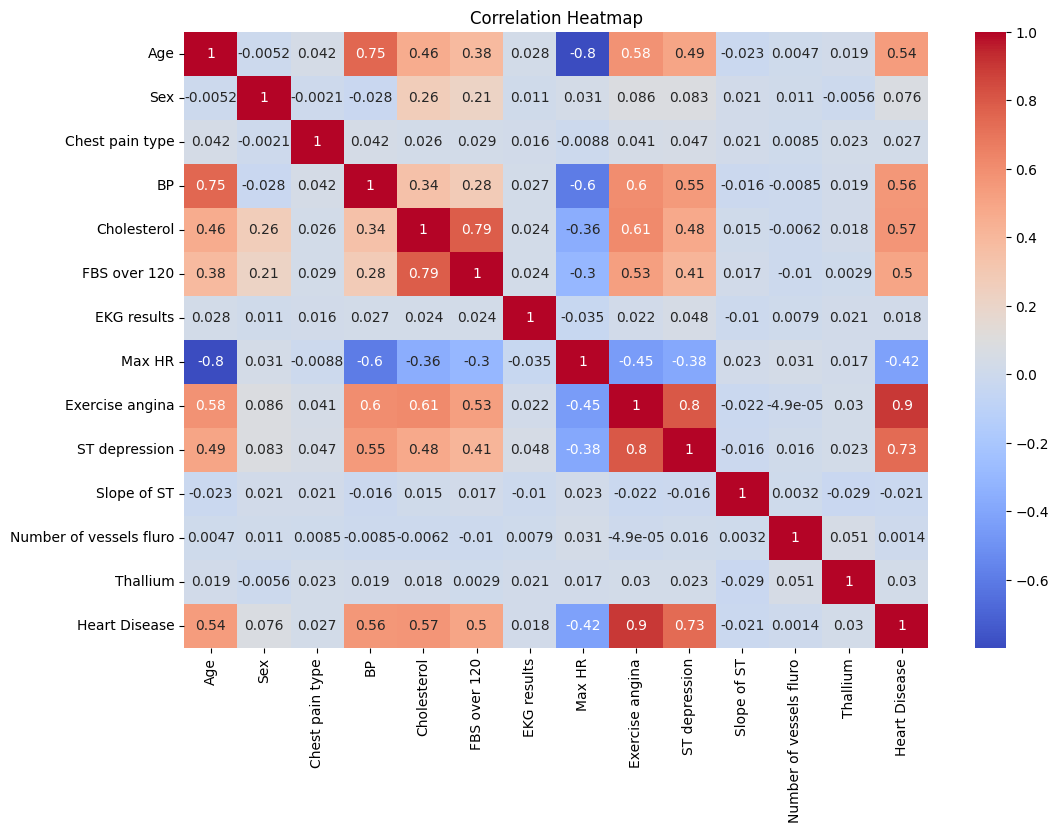

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [27]:
X = data.drop('Heart Disease', axis=1)
y = data['Heart Disease']

In [28]:
# Label Encoding

In [29]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [30]:
#Min Max and Standardisation

In [31]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

X_standardized = scaler_std.fit_transform(X)

print("Standardized Data (first 5 rows):\n", X_standardized[:5])

Standardized Data (first 5 rows):
 [[ 0.23134607 -0.95254122  1.32978608  0.85470867 -0.64283336 -1.0765381
   1.18499418  0.19425272  1.0065072   1.63990871  0.0641375   0.45102777
   0.34082613]
 [-0.73777186  1.03877889 -1.29817056 -0.39576587 -0.34422299 -1.0765381
  -0.02227717  1.65459557 -0.98301029 -0.62277394 -1.12746599 -0.46035721
   0.92964394]
 [ 1.200464   -0.95254122 -1.29817056  1.64448206 -1.40293249 -1.0765381
  -0.02227717 -0.62353928  1.0065072   0.96802041 -1.12746599  1.36241275
  -1.42562728]
 [-1.22233082  1.03877889  1.32978608 -0.79065256  0.49731533  0.91869987
  -1.22954852  1.18728586  1.0065072   1.33360669  1.25574099  1.36241275
  -1.42562728]
 [-0.3224356  -0.95254122 -1.29817056 -0.19832252 -0.18134461 -1.0765381
   1.18499418  0.544735   -0.98301029 -0.35599476  0.0641375   0.45102777
   0.34082613]]


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()

X_minmax = scaler_mm.fit_transform(X)

print("Min-Max Scaled Data (first 5 rows):\n", X_minmax[:5])

Min-Max Scaled Data (first 5 rows):
 [[0.34155211 0.         0.49741748 0.54888748 0.38316467 0.
  0.46648728 0.44312793 0.40039841 0.59344852 0.233633   0.33882295
  0.32727115]
 [0.17077605 0.40170624 0.         0.36907951 0.42292704 0.
  0.23324364 0.65617021 0.         0.20293211 0.         0.16941148
  0.43636153]
 [0.51232816 0.         0.         0.6624504  0.28195136 0.
  0.23324364 0.32382426 0.40039841 0.47748731 0.         0.50823443
  0.        ]
 [0.08538803 0.40170624 0.49741748 0.31229805 0.53498463 0.39582856
  0.         0.58799668 0.40039841 0.54058385 0.46726601 0.50823443
  0.        ]
 [0.24396579 0.         0.         0.39747024 0.44461561 0.
  0.46648728 0.49425808 0.         0.24897553 0.233633   0.33882295
  0.32727115]]


In [33]:
import pandas as pd

X_standardized_df = pd.DataFrame(X_standardized, columns=X.columns)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

print(X_standardized_df.head())
print(X_minmax_df.head())

        Age       Sex  Chest pain type        BP  Cholesterol  FBS over 120  \
0  0.231346 -0.952541         1.329786  0.854709    -0.642833     -1.076538   
1 -0.737772  1.038779        -1.298171 -0.395766    -0.344223     -1.076538   
2  1.200464 -0.952541        -1.298171  1.644482    -1.402932     -1.076538   
3 -1.222331  1.038779         1.329786 -0.790653     0.497315      0.918700   
4 -0.322436 -0.952541        -1.298171 -0.198323    -0.181345     -1.076538   

   EKG results    Max HR  Exercise angina  ST depression  Slope of ST  \
0     1.184994  0.194253         1.006507       1.639909     0.064137   
1    -0.022277  1.654596        -0.983010      -0.622774    -1.127466   
2    -0.022277 -0.623539         1.006507       0.968020    -1.127466   
3    -1.229549  1.187286         1.006507       1.333607     1.255741   
4     1.184994  0.544735        -0.983010      -0.355995     0.064137   

   Number of vessels fluro  Thallium  
0                 0.451028  0.340826  
1       

In [34]:
from sklearn.preprocessing import LabelEncoder

df = data.copy()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

In [35]:
print(data['Heart Disease'].isnull().sum())

0


In [36]:
print(y.unique())

[1.         0.         2.49751243]


In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [38]:
print(X.dtypes)

Age                        float64
Sex                        float64
Chest pain type            float64
BP                         float64
Cholesterol                float64
FBS over 120               float64
EKG results                float64
Max HR                     float64
Exercise angina            float64
ST depression              float64
Slope of ST                float64
Number of vessels fluro    float64
Thallium                   float64
dtype: object


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

model = LogisticRegression(max_iter=1000)

cv = StratifiedKFold(n_splits=5)

sfs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=6,
    direction='forward',
    cv=cv
)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]

print("Selected Features:", list(selected_features))

Selected Features: ['Age', 'Sex', 'Chest pain type', 'BP', 'FBS over 120', 'Exercise angina']


In [40]:
X.shape

(2795, 13)

In [41]:
y.shape

(2795,)

In [42]:
from sklearn.model_selection import train_test_split

# Split into train and test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
#selected features
X_selected = X[selected_features]

In [44]:
# Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [46]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

# Optional: Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9552772808586762
Precision: 1.0
Recall: 0.9163879598662207
F1-Score: 0.956369982547993
Confusion Matrix:
 [[260   0]
 [ 25 274]]


In [50]:
from sklearn.model_selection import cross_val_score

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(lr_model, X_selected, y, cv=5, scoring='accuracy')
print("Logistic Regression CV Accuracy:", cv_scores.mean())

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
cv_scores_knn = cross_val_score(knn_model, X_selected, y, cv=5, scoring='accuracy')
print("KNN CV Accuracy:", cv_scores_knn.mean())

Logistic Regression CV Accuracy: 0.9470483005366725
KNN CV Accuracy: 0.8293381037567084


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[260   0]
 [ 25 274]]


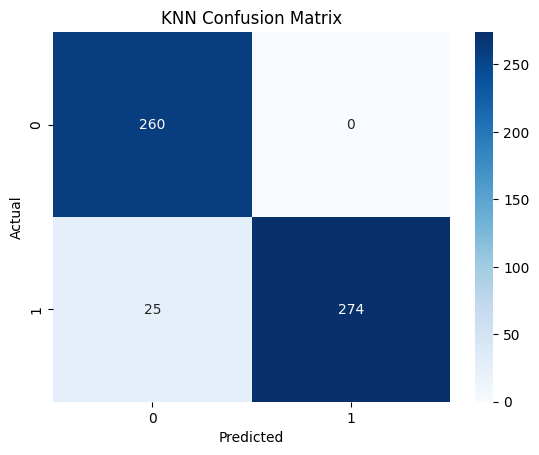

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

In [67]:
import pickle

artifacts = {
    'model': lr_model,
    'features': selected_features,
    'scaler': scaler_mm
}

with open('heart_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

In [68]:
import pickle

with open('heart_model.pkl', 'rb') as f:
    data = pickle.load(f)

model = data['model']
features_list = data['features']
scaler = data['scaler']


In [69]:
user_input = []

print("Enter patient details:")

for feature in features_list:
    value = float(input(f"{feature}: "))
    user_input.append(value)

Enter patient details:


Age:  60
Sex:  1
Chest pain type:  3
BP:  5
FBS over 120:  6
Exercise angina:  2


In [70]:
import numpy as np

input_array = np.array([user_input])

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)   #  THIS MUST RUN

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [74]:
print(model)

LogisticRegression()


In [75]:
import pickle

with open('heart_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'features': selected_features,
        'scaler': None   # or your scaler if used correctly
    }, f)

print("Saved after training!")

Saved after training!


In [76]:
with open('heart_model.pkl', 'rb') as f:
    data = pickle.load(f)

model = data['model']

prediction = model.predict(input_array)

In [77]:
print(hasattr(model, "coef_"))

True


In [78]:
prediction = model.predict(input_array)

In [ ]:
if prediction[0] == 1:
    print("\n The person HAS heart disease")
else:
    print("\n The person does NOT have heart disease")

In [80]:
prob = model.predict_proba(input_array)

print(f"\nProbability of Heart Disease: {prob[0][1]*100:.2f}%")


Probability of Heart Disease: 0.00%


In [81]:
print(f"Confidence: {prob[0][1]*100:.2f}%")

Confidence: 0.00%
